In [7]:
import os
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import seaborn as sns

In [8]:
# Importacion y Configuracion de imagenes .fits
BASE_DIR = "/media/aco/ssd/Users/Charcas/Downloads/LSST Static Lens Finding Challenge/"  # carpeta raíz con tus 4 subcarpetas
CLASSES= [
    "hsc_lenses_r",
    "hsc_nonlenses_r",
    "slsim_lenses_r",
    "slsim_nonlenses_r",
]

IMG_SIZE = (41, 41)  # tamaño de tus FITS
all_images = [] # Lista para guardar todas las imagenes de los dataset
all_labels = [] # Lisra par guardar todas las etiquetas de los dataset

"""
Las etiquetas son 
0 - hsc_lenses_r, 
0 - slsim_lenses_r, 

1 - hsc_nonlenses_r,
1 - slsim_nonlenses_r
"""

# Nuevo mapeo de clases a etiquetas binarias
BINARY_LABELS = {
    "hsc_lenses_r": 0,
    "slsim_lenses_r": 0,

    "hsc_nonlenses_r": 1,
    "slsim_nonlenses_r": 1,
}


# Lee un FITS y devuelve la imagen normalizada (41x41)
def read_fits(path):
    with fits.open(path, memmap=False) as hdul:
        arr = hdul[1].data[0][1].astype(np.float32)
    vmin, vmax = np.min(arr), np.max(arr)
    arr = (arr - vmin) / (vmax - vmin + 1e-8)
    return arr

# Carga del dataset con nuevas etiquetas
for class_name in CLASSES:
    label = BINARY_LABELS[class_name]   # <<< etiqueta 0 o 1

    folder = os.path.join(BASE_DIR, class_name)
    files = sorted([f for f in os.listdir(folder) if f.endswith(".fits")])
    print(f"Cargando {class_name} ({len(files)} imágenes)...")

    for f in tqdm(files):
        path = os.path.join(folder, f)
        try:
            img = read_fits(path)
            all_images.append(img)
            all_labels.append(label)
        except Exception as e:
            print(f"⚠️ Error con {f}: {e}")

# Convertir a NumPy arrays
X = np.array(all_images, dtype=np.float32)
y = np.array(all_labels, dtype=np.int32)

# Añadir canal (41,41,1), tamaño de la imagen + un canal que especifica la banda o canales a usar
X = np.expand_dims(X, axis=-1)

# Guardar
np.save("X.npy", X)
np.save("y.npy", y)

print(f"\nGuardado: X.shape={X.shape}, y.shape={y.shape}")

Cargando hsc_lenses_r (5000 imágenes)...


  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:59<00:00, 83.82it/s] 


Cargando hsc_nonlenses_r (5000 imágenes)...


100%|██████████| 5000/5000 [00:59<00:00, 83.84it/s] 


Cargando slsim_lenses_r (5000 imágenes)...


100%|██████████| 5000/5000 [00:58<00:00, 85.55it/s] 


Cargando slsim_nonlenses_r (5000 imágenes)...


100%|██████████| 5000/5000 [00:58<00:00, 85.91it/s] 



Guardado: X.shape=(20000, 41, 41, 1), y.shape=(20000,)


In [16]:
from sklearn.utils import shuffle
X, y = shuffle(X, y, random_state=42)

In [17]:
from sklearn.model_selection import train_test_split

# Split 80/20 
SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Verifica balance por clase
def counts(label_array):
    return dict(Counter(label_array.tolist()))

print("Shape X_train:", X_train.shape, " | y_train:", y_train.shape)
print("Shape X_test :", X_test.shape,  " | y_test :", y_test.shape)
print("Clases en train:", counts(y_train))
print("Clases en test :", counts(y_test))

# 4) (Opcional) Guarda los splits para usarlos directo en TensorFlow
np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)
np.save("X_test.npy",  X_test)
np.save("y_test.npy",  y_test)

Shape X_train: (16000, 41, 41, 1)  | y_train: (16000,)
Shape X_test : (4000, 41, 41, 1)  | y_test : (4000,)
Clases en train: {1: 8000, 0: 8000}
Clases en test : {1: 2000, 0: 2000}


X_train shape: (16000, 41, 41, 1)
y_train shape: (16000,)


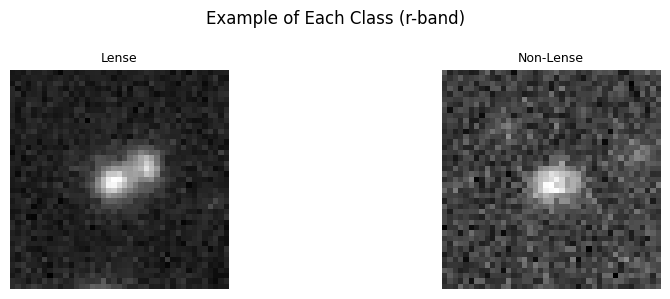

In [18]:
# Ver formas
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# Nombres de las clases (ajusta según tu orden)
class_names = ["Lense", "Non-Lense"]

# Crear una figura 1x4
plt.figure(figsize=(10, 3))

# Mostrar una imagen por clase
for label in range(2):
    # Buscar el primer índice donde y_train == label
    idx = np.where(y_train == label)[0][0]
    img = X_train[idx].squeeze()

    plt.subplot(1, 2, label + 1)
    plt.imshow(img, cmap='gray')
    plt.title(class_names[label], fontsize=9)
    plt.axis('off')

plt.suptitle("Example of Each Class (r-band)", fontsize=12)
plt.tight_layout()
plt.show()


In [19]:
import tensorflow as tf

modelo = tf.keras.Sequential([
    # Input
    tf.keras.layers.Input(shape=(41, 41, 1)),

    # Bloque 1: 32 filtros
    tf.keras.layers.Conv2D(32, (3, 3), padding="same",
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                           use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Conv2D(32, (3, 3), padding="same",
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                           use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),

    tf.keras.layers.MaxPooling2D((2, 2)),   # 41x41 -> ~20x20

    # Bloque 2: 64 filtros
    tf.keras.layers.Conv2D(64, (3, 3), padding="same",
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                           use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Conv2D(64, (3, 3), padding="same",
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                           use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),

    tf.keras.layers.MaxPooling2D((2, 2)),   # ~20x20 -> ~10x10

    # Bloque 3: 128 filtros
    tf.keras.layers.Conv2D(128, (3, 3), padding="same",
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                           use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Conv2D(128, (3, 3), padding="same",
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                           use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),

    # Head de clasificación
    tf.keras.layers.GlobalAveragePooling2D(),   # evita Flatten con muchos parámetros
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")  # 2 clases (classificación binaria)
])


In [20]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

loss = tf.keras.losses.BinaryCrossentropy()


modelo.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3), # Optimizador de los pesos
    loss=loss, # Funcion de perdida, cuan lejos estan las predicciones
    metrics=["accuracy", tf.keras.metrics.AUC()]
)

callbacks = [
    ModelCheckpoint(
        filepath="best.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),
    CSVLogger("train_log.csv", append=False)
]

hist = modelo.fit(
    X_train, y_train,
    epochs=50,                     # Numero de epocas maximo
    batch_size=64,
    validation_split=0.15,           # usar 15% del train como validación
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.6659 - auc_5: 0.7350 - loss: 0.6248
Epoch 1: val_accuracy improved from None to 0.50417, saving model to best.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 140s 631ms/step - accuracy: 0.7300 - auc_5: 0.8166 - loss: 0.5563 - val_accuracy: 0.5042 - val_auc_5: 0.4898 - val_loss: 1.1874 - learning_rate: 0.0010
Epoch 2/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.8091 - auc_5: 0.8933 - loss: 0.4481
Epoch 2: val_accuracy did not improve from 0.50417
213/213 ━━━━━━━━━━━━━━━━━━━━ 130s 611ms/step - accuracy: 0.8232 - auc_5: 0.9051 - loss: 0.4266 - val_accuracy: 0.4583 - val_auc_5: 0.5069 - val_loss: 1.3188 - learning_rate: 0.0010
Epoch 3/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.8475 - auc_5: 0.9245 - loss: 0.3853
Epoch 3: val_accuracy improved from 0.50417 to 0.86792, saving model to best.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 142s 611ms/step - accuracy: 0.8482 - auc_5: 0.9258 - loss: 0.3826 - val_accuracy: 0

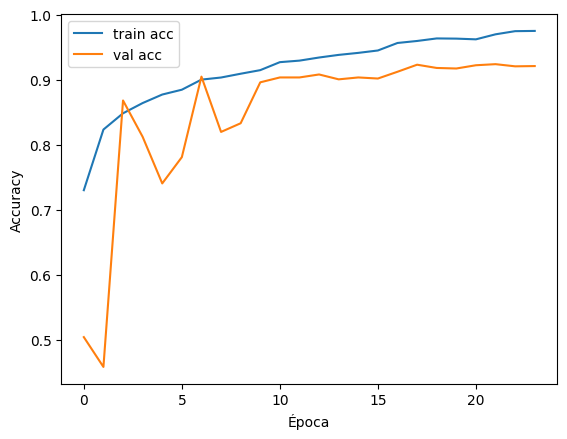

In [21]:
plt.plot(hist.history["accuracy"], label="train acc")
plt.plot(hist.history["val_accuracy"], label="val acc")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [22]:
modelo.load_weights("best.keras")
modelo.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 41, 41, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 41, 41, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 41, 41, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 41, 41, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 41, 41, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_19 (ReLU)                 │ (None, 41, 41, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 20, 20, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 20, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 20, 20, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 20, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 10, 10, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_22 (ReLU)                 │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 10, 10, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_23 (ReLU)                 │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 886,501 (3.38 MB)

 Trainable params: 295,201 (1.13 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 590,404 (2.25 MB)

In [25]:
test_loss, test_acc, test_auc = modelo.evaluate(X_test, y_test, batch_size=64)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)
print("Test AUC:", test_auc)


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.9095 - auc_5: 0.9654 - loss: 0.3116
Test loss: 0.3116256296634674
Test accuracy: 0.909500002861023
Test AUC: 0.9654324650764465


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step


<Figure size 600x600 with 0 Axes>

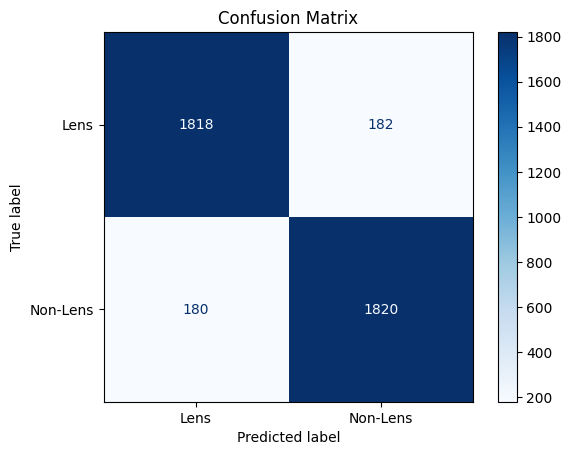

In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predicciones del modelo (probabilidades entre 0 y 1)
y_pred_prob = modelo.predict(X_test, batch_size=64)

# Convertir a clases (0 o 1)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Lens", "Non-Lens"])

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()


In [32]:
# Reporte detallado
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

              precision    recall  f1-score   support

      lenses      0.910     0.909     0.909      2000
   nonlenses      0.909     0.910     0.910      2000

    accuracy                          0.909      4000
   macro avg      0.910     0.909     0.909      4000
weighted avg      0.910     0.909     0.909      4000

